In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
ss_df = pd.read_excel('Sales-Superstore-Dataset.xlsx')

In [3]:
ss_df.head()

,Category,City,Country,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,...,Ship Date,Ship Mode,State,Sub-Category,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales
0,Office Supplies,Houston,United States,Darren Powers,Message Book,2011-01-04,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Central,...,2011-01-08,Standard Class,Texas,Paper,0.2,1,6,0.34,2,16
1,Office Supplies,Naperville,United States,Phillina Ober,GBC,2011-01-05,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,Central,...,2011-01-09,Standard Class,Illinois,Binders,0.8,1,-5,-1.55,2,4
2,Office Supplies,Naperville,United States,Phillina Ober,Avery,2011-01-05,CA-2011-112326,60540,Avery 508,Central,...,2011-01-09,Standard Class,Illinois,Labels,0.2,1,4,0.36,3,12
3,Office Supplies,Naperville,United States,Phillina Ober,SAFCO,2011-01-05,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,Central,...,2011-01-09,Standard Class,Illinois,Storage,0.2,1,-65,-0.24,3,273
4,Office Supplies,Philadelphia,United States,Mick Brown,Avery,2011-01-06,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,...,2011-01-13,Standard Class,Pennsylvania,Art,0.2,1,5,0.25,3,20


In [4]:
ss_df.shape

(9994, 21)

In [5]:
ss_df.dtypes

Category                     object
City                         object
Country                      object
Customer Name                object
Manufacturer                 object
Order Date           datetime64[ns]
Order ID                     object
Postal Code                   int64
Product Name                 object
Region                       object
Segment                      object
Ship Date            datetime64[ns]
Ship Mode                    object
State                        object
Sub-Category                 object
Discount                    float64
Number of Records             int64
Profit                        int64
Profit Ratio                float64
Quantity                      int64
Sales                         int64
dtype: object

In [6]:
ss_df = ss_df.drop_duplicates()

In [7]:
ss_df.shape

(9993, 21)

In [8]:
ss_df.columns = ss_df.columns.str.lower().str.replace(' ', '_')

In [9]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales'],
      dtype='object')

Question 1: Calculate the total sales for each year and determine the year-over-year (YoY) growth
percentage.

In [10]:
ss_df['order_date'].dt.year.unique()

array([2011, 2012, 2013, 2014], dtype=int32)

In [11]:
ss_df['year'] = ss_df['order_date'].dt.year
yearly_sales = (
    ss_df.groupby('year')['sales']
    .sum()
    .reset_index(name='yearly_sales')
)

yearly_sales['yoy_growth_%'] = yearly_sales['yearly_sales'].pct_change() * 100
yearly_sales

,year,yearly_sales,yoy_growth_%
0,2011,483974,NaN
1,2012,470560,-2.771636
2,2013,608523,29.318897
3,2014,734016,20.622557


Question 2. Identify the top 10 customers by total sales and compute their contribution to total company
sales

In [12]:
TOP_10_customers = ss_df.groupby('customer_name')['sales'].sum().reset_index(name ='customer_sales').sort_values(by ='customer_sales',ascending =False).head(10)
total_sales = ss_df['sales'].sum()
TOP_10_customers['perc_contr_to_comp_sales'] = TOP_10_customers['customer_sales']*100.0 / total_sales
TOP_10_customers

,customer_name,customer_sales,perc_contr_to_comp_sales
686,Sean Miller,25042,1.090170
730,Tamara Chand,19050,0.829316
622,Raymond Buch,15117,0.658098
757,Tom Ashbrook,14596,0.635417
6,Adrian Barton,14476,0.630193
441,Ken Lonsdale,14175,0.617090
671,Sanjit Chand,14145,0.615784
334,Hunter Lopez,12875,0.560496
672,Sanjit Engle,12209,0.531502
156,Christopher Conant,12128,0.527976


Question 3. Determine which product sub-category has the highest profit margin overall.

In [13]:
subcategory_profit = (
    ss_df.groupby('sub-category')
    .agg({'sales':'sum', 'profit':'sum'})
    .reset_index()
)

subcategory_profit['profit_margin'] = (
    subcategory_profit['profit'] / subcategory_profit['sales']
)

best_subcategory = (
    subcategory_profit
    .sort_values(by='profit_margin', ascending=False)
    .head(1)
)
best_subcategory

,sub-category,sales,profit,profit_margin
10,Labels,12507,5558,0.444391


Question 4. Compute cumulative sales over time and visualize the trend.

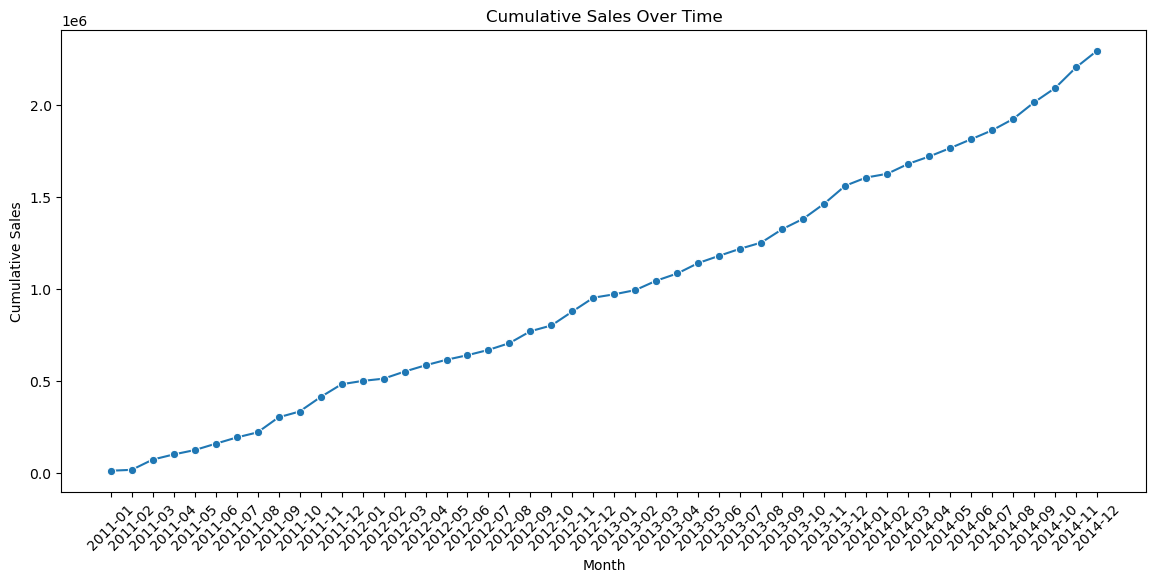

In [14]:
ss_df['month_year'] = ss_df['order_date'].dt.to_period('M')
monthly_sales = (
    ss_df.groupby('month_year')['sales']
    .sum()
    .reset_index()
)
monthly_sales['cumulative_sales'] = monthly_sales['sales'].cumsum()
monthly_sales['month_year'] = monthly_sales['month_year'].astype(str)
plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_sales,
    x='month_year',
    y='cumulative_sales',
    marker = 'o'
)

plt.xticks(rotation=45)
plt.title('Cumulative Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Cumulative Sales')

plt.show()


Question 5. Identify the top 3 selling products within each category using groupby and ranking.

In [15]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales', 'year', 'month_year'],
      dtype='object')

In [16]:
sales_by_category = (
    ss_df.groupby(['category','product_name'])['sales']
    .sum()
    .reset_index()
)
sales_by_category['rank'] = (
    sales_by_category.groupby('category')['sales']
    .rank(method='first', ascending=False)
)
top_3_products = sales_by_category[sales_by_category['rank'] <= 3].sort_values(['category','rank'])

top_3_products

,category,product_name,sales,rank
206,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870,1.0
321,Furniture,"Riverside Palais Royal Lawyers Bookcase, Royal...",15611,2.0
40,Furniture,Bretford Rectangular Conference Table Tops,12997,3.0
773,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Bin...,27454,1.0
802,Office Supplies,GBC DocuBind TL300 Electric Binding System,19824,2.0
804,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19026,3.0
1486,Technology,Canon imageCLASS 2200 Advanced Copier,61600,1.0
1505,Technology,Cisco TelePresence System EX90 Videoconferenci...,22638,2.0
1548,Technology,Hewlett Packard LaserJet 3310 Copier,18840,3.0


In [17]:
ss_df.shape

(9993, 23)

In [18]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales', 'year', 'month_year'],
      dtype='object')

Question 6. Calculate the rolling 30-day average of sales.

In [19]:
ss_df.sort_values(by='order_date',inplace =True)
daily_sales = ss_df.groupby('order_date')['sales'].sum().reset_index()
daily_sales['30_day_rolling_avg'] = (daily_sales['sales'].rolling(window=30).mean())
daily_sales.iloc[30:60]

,order_date,sales,30_day_rolling_avg
30,2011-02-13,130,594.400000
31,2011-02-15,577,604.000000
32,2011-02-16,21,604.033333
33,2011-02-17,9,457.433333
34,2011-02-18,54,456.333333
35,2011-02-19,38,456.266667
36,2011-02-21,95,457.600000
37,2011-02-22,9,457.566667
38,2011-02-23,19,339.733333
39,2011-02-24,11,338.033333


Question 7. Determine the average shipping delay for each region.

In [20]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales', 'year', 'month_year'],
      dtype='object')

In [21]:
ss_df.drop('30_day_rolling_avg_sales',axis =1,inplace =True)
ss_df.columns

KeyError: "['30_day_rolling_avg_sales'] not found in axis"

In [ ]:
ss_df.dtypes

In [ ]:
ss_df['shipping_delay_days'] = (ss_df['ship_date'] - ss_df['order_date']).dt.days
average_shipping_delay_by_region = ss_df.groupby('region')['shipping_delay_days'].mean().reset_index(name = 'avg_shipping_delay')
average_shipping_delay_by_region

Question 8. Identify customers who placed more than 10 orders.

In [ ]:
customers_with_more_than_10_orders = (
    ss_df.groupby('customer_name')['order_id']
    .count()
    .reset_index(name='total_orders')
    .loc[lambda x: x['total_orders'] > 10]
    .sort_values(by='total_orders', ascending=False)
)
customers_with_more_than_10_orders

In [ ]:
customers_with_greater_than_10_orders = (
    ss_df.groupby('customer_name')['order_id']
    .count()
    .reset_index(name='total_orders')
    .query('total_orders > 10')
    .sort_values(by='total_orders', ascending=False)
)
customers_with_greater_than_10_orders

Question 9. Calculate the median sales value for each product category

In [ ]:
median_sales_by_category = ss_df.groupby('category')['sales'].median().reset_index(name ='median_sales').sort_values(by='median_sales',ascending =False)
median_sales_by_category

Question 10. Determine which state has the highest average order value.

In [ ]:
state_with_highest_avg_order = ss_df.groupby('state')['sales'].mean().reset_index(name ='avg_order_value').nlargest(1,'avg_order_value')
state_with_highest_avg_order

Question 11. Identify products that consistently generate negative profit.

In [ ]:
loss_products = (
    ss_df.groupby('product_name')['profit']
    .sum()
    .reset_index(name='total_profit')
    .query('total_profit < 0')
    .sort_values('total_profit')
)
loss_products

Question 12. Compute the correlation matrix for all numeric columns and identify the strongest correlations.

In [ ]:
cols_to_remove = ['number_of_records', 'postal_code', 'profit_ratio']
corr = ss_df.drop(columns=cols_to_remove).corr(numeric_only=True)
corr

Question 13. Calculate monthly total sales and visualize seasonal patterns

In [ ]:
ss_df.dtypes

In [ ]:
monthly_total_sales = ss_df.groupby('month_year')['sales'].sum().reset_index(name ='monthly_sales').\
                           sort_values(by = 'month_year',ascending = True)
monthly_total_sales['month_year'] = monthly_total_sales['month_year'].astype(str)
plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_total_sales,
    x='month_year',
    y='monthly_sales',
    marker = 'o'
)

plt.xticks(rotation=45)
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Monthly Sales')

plt.show()

Comments on Seasonality: 
    
1. End-of-year spikes
Sales appear higher in Oct–Dec, especially:
late 2013
late 2014

This often happens due to:
holiday shopping
year-end business purchases

2. Early-year dips

Some January–February months show lower sales, which can indicate post-holiday slowdown.

3. Increasing yearly peaks

The peaks get larger over time:

2011 peak < 2013 peak < 2014 peak

This suggests overall growth in sales over time.

Question 14. Identify the top performing category in each region.

In [ ]:
category_sales_by_region = ss_df.groupby(['region','category'])['sales'].sum().reset_index(name ='total_sales')
category_sales_by_region['rank'] = (
    category_sales_by_region.groupby('region')['total_sales']
    .rank(method='first', ascending=False)
)
top_performing_category = category_sales_by_region[category_sales_by_region['rank'] == 1]
top_performing_category

Question 15. Calculate the percentage of total sales contributed by each category.

In [ ]:
sales_by_category = ss_df.groupby('category')['sales'].sum().reset_index(name = 'total_category_sales').\
    assign(percent_contribution=lambda x: x['total_category_sales']*100/ss_df['sales'].sum())
sales_by_category

In [ ]:
total_sales = ss_df['sales'].sum()

tot_sales_by_category = (
    ss_df.groupby('category')['sales']
    .sum()
    .reset_index(name='total_category_sales')
)

tot_sales_by_category['percent_contribution'] = (
    tot_sales_by_category['total_category_sales'] * 100 / total_sales
)
tot_sales_by_category

Question 16. Determine the most profitable product in each sub-category.

In [ ]:
ss_df['sub-category'].unique()

In [ ]:
ss_df['product_name'].nunique()

In [ ]:
product_profits_in_subcategory = ss_df.groupby(['sub-category','product_name'])['profit'].sum().\
                                       reset_index(name ='total_profit')
product_profits_in_subcategory['rank'] = (
    product_profits_in_subcategory.groupby('sub-category')['total_profit']
    .rank(method='first', ascending=False)
)
most_profitable_product_by_subcategory= product_profits_in_subcategory[product_profits_in_subcategory['rank'] == 1]
most_profitable_product_by_subcategory

In [ ]:
most_profitable_product_each_subcategory = (
    ss_df.groupby(['sub-category','product_name'])['profit']
    .sum()
    .reset_index(name='total_profit')
    .sort_values(['sub-category','total_profit'], ascending=[True, False])
    .drop_duplicates('sub-category')
)
most_profitable_product_each_subcategory

Question 17. Calculate customer lifetime value (total sales per customer).

In [ ]:
total_sales_per_customer = ss_df.groupby('customer_name')['sales'].sum().reset_index(name ='total_sales')\
                                .sort_values(by ='total_sales',ascending = False)

total_sales_per_customer

Question 18. Segment customers into quartiles based on total sales.

In [ ]:
total_sales_per_customer['sales_quartile'] = pd.qcut(
    total_sales_per_customer['total_sales'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)
mean_quartile_sales = total_sales_per_customer.groupby('sales_quartile')['total_sales'].mean()
mean_quartile_sales

Question 19. Identify the top 5 cities generating the highest profit

In [ ]:
TOP5_cities_by_profit = ss_df.groupby('city')['profit'].sum().reset_index(name = 'total_profit')\
                             .sort_values(by ='total_profit',ascending =False).head()
TOP5_cities_by_profit

In [23]:
Most_profitable_5_cities = ss_df.groupby('city')['profit'].sum().reset_index(name = 'total_profit')\
                                .nlargest(5,'total_profit')
Most_profitable_5_cities

,city,total_profit
329,New York City,62019
266,Los Angeles,30439
452,Seattle,29144
438,San Francisco,17494
123,Detroit,13178


Question 20. Determine the average discount applied to each category.

In [22]:
avg_discnt_by_category = ss_df.groupby('category')['discount'].mean().reset_index(name ='average_discount')
avg_discnt_by_category

,category,average_discount
0,Furniture,0.173863
1,Office Supplies,0.157285
2,Technology,0.132323


Question 21. Identify orders with unusually high shipping delays (outliers).

In [24]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales', 'year', 'month_year'],
      dtype='object')

In [26]:
ss_df['shipping_days'] = (ss_df['ship_date'] - ss_df['order_date']).dt.days

In [27]:
ss_df['shipping_days'].describe()

count    9993.000000
mean        3.958871
std         1.747184
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64

In [35]:
z_scores = (stats.zscore(ss_df['shipping_days']))

In [40]:
outliers = ss_df[ss_df['shipping_days'] > 6]
outliers

,category,city,country,customer_name,manufacturer,order_date,order_id,postal_code,product_name,region,...,sub-category,discount,number_of_records,profit,profit_ratio,quantity,sales,year,month_year,shipping_days
4,Office Supplies,Philadelphia,United States,Mick Brown,Avery,2011-01-06,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,...,Art,0.2,1,5,0.25,3,20,2011,2011-01,7
81,Office Supplies,Saint Petersburg,United States,Eric Barreto,Other,2011-02-03,CA-2011-123400,33710,Surelock Post Binders,South,...,Binders,0.7,1,-12,-0.67,2,18,2011,2011-02,7
82,Technology,Saint Petersburg,United States,Eric Barreto,AT&T,2011-02-03,CA-2011-123400,33710,AT&T 17929 Lendline Telephone,South,...,Phones,0.2,1,14,0.08,5,181,2011,2011-02,7
112,Office Supplies,Chicago,United States,Delfina Latchford,Other,2011-02-18,CA-2011-154165,60653,Staples,Central,...,Art,0.2,1,9,0.16,14,54,2011,2011-02,7
164,Office Supplies,Denver,United States,Kean Thornton,Boston,2011-03-10,US-2011-140116,80219,"BOSTON Ranger #55 Pencil Sharpener, Black",West,...,Art,0.2,1,9,0.11,4,83,2011,2011-03,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9974,Technology,New York City,United States,Jennifer Ferguson,Other,2014-12-29,CA-2014-164826,10024,Cush Cases Heavy Duty Rugged Cover Case for Sa...,East,...,Phones,0.0,1,4,0.27,3,15,2014,2014-12,7
9973,Office Supplies,New York City,United States,Jennifer Ferguson,Avery,2014-12-29,CA-2014-164826,10024,Avery 473,East,...,Labels,0.0,1,35,0.48,7,72,2014,2014-12,7
9972,Office Supplies,New York City,United States,Jennifer Ferguson,Other,2014-12-29,CA-2014-164826,10024,OIC Bulk Pack Metal Binder Clips,East,...,Fasteners,0.0,1,6,0.46,4,14,2014,2014-12,7
9971,Office Supplies,New York City,United States,Jennifer Ferguson,Storex,2014-12-29,CA-2014-164826,10024,Storex Dura Pro Binders,East,...,Binders,0.2,1,11,0.34,7,33,2014,2014-12,7


Comment on Outliers:
Shipping delays range between 0 and 7 days with a mean of ~4 days. 
No statistical outliers were detected using the 3-standard-deviation rule due to the operationally constrained range. 
Instead, shipments taking 6–7 days were flagged as potential operational delays.

Question 22. Calculate monthly profit trends for each category

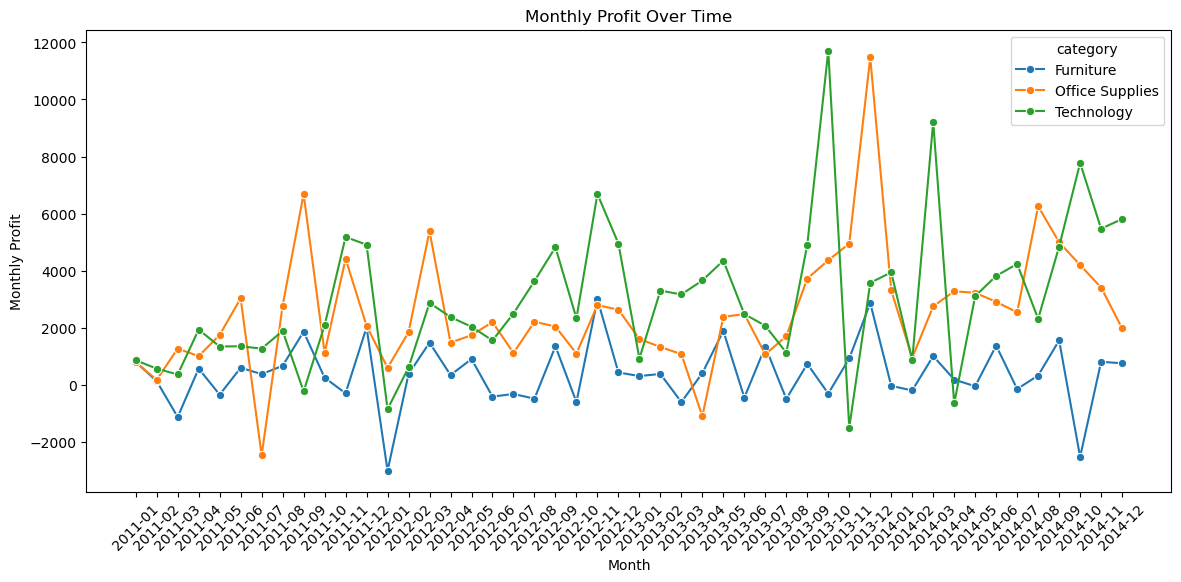

In [48]:
monthly_profit_by_category = ss_df.groupby(['month_year','category'])['profit'].sum().reset_index(name ='monthly_profit')\
                                   .sort_values(by = ['category', 'month_year'], ascending =[True,True])
monthly_profit_by_category['month_year'] = monthly_profit_by_category['month_year'].astype(str)
plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_profit_by_category,
    x='month_year',
    y='monthly_profit',
    hue ='category',
    marker = 'o'
)

plt.xticks(rotation=45)
plt.title('Monthly Profit Over Time')
plt.xlabel('Month')
plt.ylabel('Monthly Profit')

plt.show()


Question 23. Determine the most frequently purchased product per customer

In [62]:
most_frequent_product_by_customer = ss_df.groupby(['customer_name','product_name']).size()\
                                         .reset_index(name ='purchase_count')
most_frequent_product_by_customer['rank'] = (
    most_frequent_product_by_customer
    .groupby('customer_name')['purchase_count']
    .rank(method='first', ascending=False)
)

result = most_frequent_product_by_customer[
    most_frequent_product_by_customer['rank'] == 1
]
result[result['purchase_count'] == 3]

,customer_name,product_name,purchase_count,rank
2220,Cynthia Delaney,Staples,3,1.0
6141,Mark Cousins,Staples,3,1.0
6243,Matt Abelman,Staples,3,1.0


Questio 24. Compute the ratio of profit to sales for each order and identify the highest ratios

In [69]:
ss_df = ss_df[ss_df['sales'] > 0]
ss_df.shape

(9992, 25)

In [70]:
ss_df['profit_to_sales_ratio'] = ss_df['profit'] /ss_df['sales']
ss_df.sort_values(by = 'profit_to_sales_ratio', ascending =False).head(10)

/tmp/ipykernel_140/38716406.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ss_df['profit_to_sales_ratio'] = ss_df['profit'] /ss_df['sales']


,category,city,country,customer_name,manufacturer,order_date,order_id,postal_code,product_name,region,...,discount,number_of_records,profit,profit_ratio,quantity,sales,year,month_year,shipping_days,profit_to_sales_ratio
4394,Office Supplies,Houston,United States,Dario Medina,Prang,2013-03-22,CA-2013-163153,77036,Prang Dustless Chalk Sticks,Central,...,0.2,1,1,0.38,1,1,2013,2013-03,4,1.000000
8778,Office Supplies,San Jose,United States,Neola Schneider,Wilson Jones,2014-10-02,CA-2014-129378,95123,Wilson Jones Easy Flow II Sheet Lifters,West,...,0.2,1,1,0.35,1,1,2014,2014-10,1,1.000000
3087,Office Supplies,Auburn,United States,Tamara Manning,OIC,2012-09-12,CA-2012-102015,13021,"OIC Binder Clips, Mini, 1/4"" Capacity, Black",East,...,0.0,1,1,0.47,1,1,2012,2012-09,6,1.000000
1895,Office Supplies,Tampa,United States,Craig Carreira,Prang,2011-12-23,CA-2011-154158,33614,Prang Dustless Chalk Sticks,South,...,0.2,1,1,0.38,1,1,2011,2011-12,4,1.000000
5286,Office Supplies,Oakland,United States,Craig Yedwab,Avery,2013-08-16,CA-2013-166163,94601,Avery 488,West,...,0.0,1,2,0.48,1,3,2013,2013-08,5,0.666667
2106,Office Supplies,Leominster,United States,Sung Shariari,Avery,2012-02-25,CA-2012-154900,1453,Avery 518,East,...,0.0,1,2,0.48,1,3,2012,2012-02,5,0.666667
402,Office Supplies,Baltimore,United States,Muhammed Yedwab,Avery,2011-04-28,CA-2011-118976,21215,Avery 488,East,...,0.0,1,2,0.48,1,3,2011,2011-04,5,0.666667
951,Office Supplies,Newark,United States,Karl Braun,Other,2011-08-26,CA-2011-103331,19711,Avoid Verbal Orders Carbonless Minifold Book,East,...,0.0,1,2,0.46,1,3,2011,2011-08,6,0.666667
9615,Office Supplies,New York City,United States,Chuck Sachs,Avery,2014-12-04,CA-2014-148691,10009,Avery 520,East,...,0.0,1,2,0.48,1,3,2014,2014-12,6,0.666667
5160,Office Supplies,Roseville,United States,Damala Kotsonis,Other,2013-07-22,CA-2013-160941,95661,Self-Adhesive Removable Labels,West,...,0.0,1,2,0.48,1,3,2013,2013-07,5,0.666667


Question 25. Identify which region experiences the highest average discount.

In [73]:
highest_discount_region = ss_df.groupby('region')['discount'].mean().nlargest(1)
highest_discount_region

region
Central    0.240112
Name: discount, dtype: float64

Question 26. Calculate the top 5 most profitable states.

In [74]:
TOP5_most_profitable_states = ss_df.groupby('state')['profit'].sum().reset_index(name='total_profit')\
                                   .nlargest(5,'total_profit')
TOP5_most_profitable_states

,state,total_profit
3,California,76368
30,New York,74020
45,Washington,33390
20,Michigan,24458
44,Virginia,18600


Question 27. Determine the number of orders placed by each segment each year.

In [75]:
number_of_orders_by_segment_per_year = ss_df.groupby(['segment', 'year'])['order_id'].count()\
                                            .reset_index(name = 'number_of_orders')
number_of_orders_by_segment_per_year

,segment,year,number_of_orders
0,Consumer,2011,1070
1,Consumer,2012,1125
2,Consumer,2013,1323
3,Consumer,2014,1672
4,Corporate,2011,611
5,Corporate,2012,636
6,Corporate,2013,791
7,Corporate,2014,982
8,Home Office,2011,311
9,Home Office,2012,341


Question 28. Create a pivot table showing average sales by region and category.

In [76]:
avg_sales_table = pd.pivot_table(data =ss_df, values = 'sales',index ='region',columns ='category')
avg_sales_table

category,Furniture,Office Supplies,Technology
region,,,
Central,340.517672,117.547502,405.790476
East,346.683333,120.063668,495.315888
South,353.331325,126.293467,507.788396
West,357.312588,116.437006,420.722871


Question 29.Identify customers whose average order value exceeds the global average.

In [81]:
avg_order_value_by_customer = ss_df.groupby('customer_name')['sales'].mean().reset_index(name ='avg_order_value')
global_avg_order_value = ss_df['sales'].mean()
customers_above_global_average = avg_order_value_by_customer[avg_order_value_by_customer['avg_order_value'] > global_avg_order_value]\
                                 .sort_values(by = 'avg_order_value',ascending =False)
customers_above_global_average

,customer_name,avg_order_value
547,Mitch Willingham,1751.333333
686,Sean Miller,1669.466667
730,Tamara Chand,1587.500000
307,Grant Thornton,1558.500000
757,Tom Ashbrook,1459.600000
...,...,...
644,Robert Waldorf,233.000000
468,Liz Carlisle,232.888889
270,Erin Smith,232.850000
44,Anna Gayman,232.600000


Question 30. Compute a rolling 7-day moving average of sales.

In [86]:
rolling_df = ss_df.set_index('order_date').sort_index()
rolling_df['7_day_rolling_avg'] = rolling_df['sales'].rolling(window='7D').mean()
rolling_df[['sales','7_day_rolling_avg']]

,sales,7_day_rolling_avg
order_date,,
2011-01-04,16,16.000000
2011-01-05,4,10.000000
2011-01-05,12,10.666667
2011-01-05,273,76.250000
2011-01-06,20,65.000000
...,...,...
2014-12-31,14,188.037975
2014-12-31,3,185.725000
2014-12-31,209,186.012346


In [88]:
daily_sales = ss_df.groupby('order_date')['sales'].sum().sort_index()

rolling_df_2 = daily_sales.to_frame()

rolling_df_2['7_day_rolling_avg'] = rolling_df_2['sales'].rolling(window=7).mean()

rolling_df_2

,sales,7_day_rolling_avg
order_date,,
2011-01-04,16,NaN
2011-01-05,289,NaN
2011-01-06,20,NaN
2011-01-07,4407,NaN
2011-01-08,87,NaN
...,...,...
2014-12-27,815,3090.428571
2014-12-28,177,3061.857143
2014-12-29,1656,2992.571429


Question 31. Calculate the percentage contribution of each sub-category to its category’s sales.

In [106]:
sales_by_category_and_subcategory = ss_df.groupby(['category','sub-category'])['sales'].sum()\
                                         .reset_index(name ='sub-category_sales')  

sales_by_category_and_subcategory['category_sales'] = (
    sales_by_category_and_subcategory.groupby('category')['sub-category_sales']
    .transform('sum')
)

sales_by_category_and_subcategory['percentage_contribution'] = (
    sales_by_category_and_subcategory['sub-category_sales'] /
    sales_by_category_and_subcategory['category_sales']
) * 100

sales_by_category_and_subcategory

,category,sub-category,sub-category_sales,category_sales,percentage_contribution
0,Furniture,Bookcases,114879,741725,15.488085
1,Furniture,Chairs,328173,741725,44.244565
2,Furniture,Furnishings,91705,741725,12.363747
3,Furniture,Tables,206968,741725,27.903603
4,Office Supplies,Appliances,107538,719127,14.953965
5,Office Supplies,Art,27137,719127,3.773603
6,Office Supplies,Binders,203428,719127,28.288188
7,Office Supplies,Envelopes,16477,719127,2.291250
8,Office Supplies,Fasteners,3024,719127,0.420510
9,Office Supplies,Labels,12507,719127,1.739192


Question 32. Identify which month historically has the highest sales

In [109]:
month_with_highest_sales = ss_df.groupby('month_year')['sales'].sum().nlargest(1)\
                                .reset_index(name ='total_sales')
month_with_highest_sales

,month_year,total_sales
0,2014-11,112335


Question 33. Calculate profit variance across regions

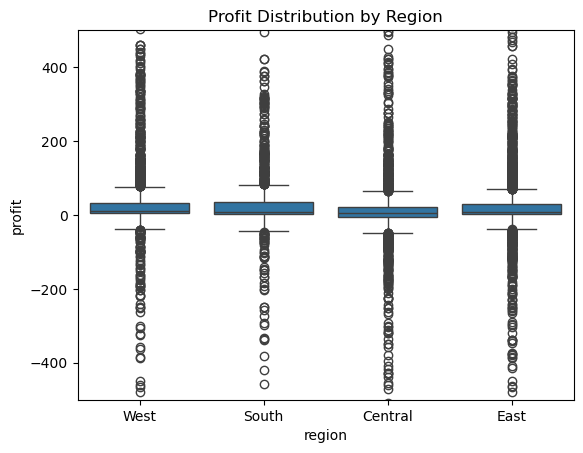

In [114]:
profit_stats_by_region = (
    ss_df.groupby('region')['profit']
    .agg(['mean','var','std'])
    .reset_index()
)
profit_stats_by_region
sns.boxplot(data=ss_df, x='region', y='profit')
plt.title('Profit Distribution by Region')
plt.ylim(-500, 500)
plt.show()

Question 34. Identify customers who only purchase from a single category

In [128]:
single_category_customers = ss_df.groupby('customer_name')['category'].nunique().reset_index(name= 'num_of_categories')\
                                 .loc[lambda x: x['num_of_categories'] == 1]
single_category_customers

,customer_name,num_of_categories
50,Anthony Garverick,1
53,Anthony O'Donnell,1
63,Astrea Jones,1
71,Bart Folk,1
94,Bobby Odegard,1
119,Bryan Spruell,1
123,Carl Jackson,1
314,Guy Phonely,1
317,Harold Dahlen,1
337,Ivan Gibson,1


In [127]:
customers_with_categories = ss_df.groupby('customer_name')['category'].unique().reset_index(name= 'customer_categories')\
                                 .loc[lambda x: x['customer_categories'].str.len() == 1]
customers_with_categories

,customer_name,customer_categories
50,Anthony Garverick,[Office Supplies]
53,Anthony O'Donnell,[Furniture]
63,Astrea Jones,[Office Supplies]
71,Bart Folk,[Office Supplies]
94,Bobby Odegard,[Office Supplies]
119,Bryan Spruell,[Office Supplies]
123,Carl Jackson,[Office Supplies]
314,Guy Phonely,[Office Supplies]
317,Harold Dahlen,[Office Supplies]
337,Ivan Gibson,[Office Supplies]


Question 35. Compute total sales and profit by shipping mode.

In [134]:
sales_profit_by_shipping_mode = ss_df.groupby('ship_mode').agg({'sales':'sum','profit':'sum'})
sales_profit_by_shipping_mode

,sales,profit
ship_mode,,
First Class,351463,48960
Same Day,128353,15893
Second Class,459233,57433
Standard Class,1358024,164074


Question 36. Determine which sub-category has the highest sales volatility.

In [139]:
sales_stats_by_subcategory = (
    ss_df.groupby('sub-category')['sales']
    .agg(['mean','var','std'])
    .reset_index()
)
sales_stats_by_subcategory['Coeff_of_Variation'] = sales_stats_by_subcategory['std']/sales_stats_by_subcategory['mean']
sales_stats_by_subcategory

,sub-category,mean,var,std,Coeff_of_Variation
0,Accessories,216.001290,1.122031e+05,334.967257,1.550765
1,Appliances,231.264516,1.515041e+05,389.235326,1.683074
2,Art,34.091709,3.614929e+03,60.124277,1.763604
3,Binders,133.570584,3.172626e+05,563.260682,4.216952
4,Bookcases,503.855263,4.080095e+05,638.756233,1.267738
5,Chairs,532.748377,3.030441e+05,550.494400,1.033310
6,Copiers,2198.970588,1.008490e+07,3175.672988,1.444163
7,Envelopes,64.870079,7.118793e+03,84.372942,1.300645
8,Fasteners,13.935484,1.535329e+02,12.390838,0.889157
9,Furnishings,95.825496,2.187419e+04,147.899257,1.543423


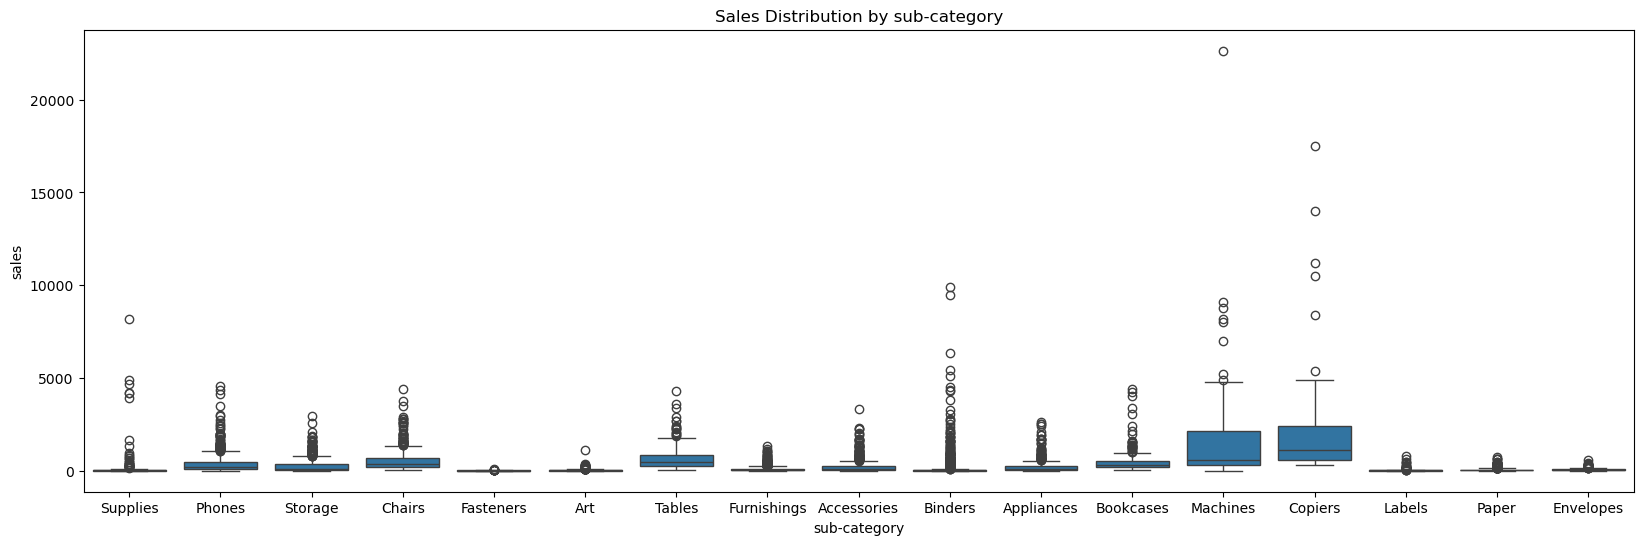

In [137]:
plt.figure(figsize=(20,6))
sns.boxplot(data=ss_df, x='sub-category', y='sales')
plt.title('Sales Distribution by sub-category')
plt.show()

# Conclusion:

## Based on Variance and Standard Deviation :

Copiers show the highest sales volatility, followed by Machines.
These sub-categories contain high-value products, leading to large fluctuations in order amounts.
Low-cost items like Fasteners and Paper exhibit very stable sales patterns.

## Based on Co-efficient of Variation

Although Copiers and Machines show the highest variance due to their large average sales values, the coefficient of variation reveals that Binders and Supplies have the highest relative sales volatility, indicating inconsistent demand patterns relative to their typical sales levels.



 Question 37.Identify orders where discount is above the average discount for that category.

In [142]:
avg_discount_by_category = ss_df.groupby('category')['discount'].mean().reset_index(name= 'avg_category_discount')
merged_df = ss_df.merge(avg_discount_by_category, on='category')
orders_above_avg_discount = merged_df.loc[
    merged_df['discount'] > merged_df['avg_category_discount']
]
orders_above_avg_discount[['discount','avg_category_discount']].head(10)

,discount,avg_category_discount
3,0.2,0.173863
4,0.2,0.157178
6,0.2,0.157178
10,0.2,0.157178
11,0.2,0.173863
12,0.3,0.173863
14,0.2,0.157178
15,0.2,0.157178
19,0.3,0.173863
23,0.2,0.173863


In [152]:
orders_above_avg_discount_2 = ss_df.loc[
    ss_df['discount'] >
    ss_df.groupby('category')['discount'].transform('mean')
]


Question 38. Calculate the average shipping time for each shipping mode.

In [146]:
avg_ship_time_by_mode = ss_df.groupby('ship_mode')['shipping_days'].mean().reset_index(name ='avg_shipping_time')
avg_ship_time_by_mode

,ship_mode,avg_shipping_time
0,First Class,2.182055
1,Same Day,0.044199
2,Second Class,3.240103
3,Standard Class,5.007543


Question 39. Determine which segment generates the most profit.

In [147]:
segment_with_most_profit = ss_df.groupby('segment')['profit'].sum().nlargest(1).reset_index(name ='total_profit')
segment_with_most_profit

,segment,total_profit
0,Consumer,134114


Question 40. Calculate the top 10 highest single orders by sales

In [153]:
TOP10_orders_by_sales = ss_df.sort_values(by='sales',ascending =False).head(10)


Question 41. Perform a hypothesis test comparing average profit between two regions.

In [154]:
ss_df.groupby('region')['profit'].mean()

region
Central    17.105943
East       32.150685
South      28.840123
West       33.838901
Name: profit, dtype: float64

In [160]:
profits_by_region = {}

for region in ss_df['region'].unique():
    profits_by_region[region] = ss_df.loc[ss_df['region'] == region, 'profit']

t_stat_ew, p_value_ew = stats.ttest_ind(profits_by_region['East'], profits_by_region['West'] , equal_var=False)
t_stat_sc, p_value_sc = stats.ttest_ind(profits_by_region['South'], profits_by_region['Central'] , equal_var=False)
t_stat_wc, p_value_wc = stats.ttest_ind(profits_by_region['West'], profits_by_region['Central'] , equal_var=False)
print("T-statistic for East and West:", t_stat_ew, "p-value for East and West:",p_value_ew)
print("T-statistic for South and Central:", t_stat_sc, "p-value for South and Central:",p_value_sc)
print("T-statistic for West and Central:", t_stat_wc, "p-value for West and Central:",p_value_wc)

T-statistic for East and West: -0.299810635874138 p-value for East and West: 0.7643341107109205
T-statistic for South and Central: 1.460172159780894 p-value for South and Central: 0.14432265783861897
T-statistic for West and Central: 2.465305332640115 p-value for West and Central: 0.013737218905486579


Conclusion:

 There is no statistically significant difference between East and West average profit.
 This makes sense because the means are very close.

 Even though South’s mean is higher than Central's, the difference is not statistically significant 

 Because statistical significance depends on:

 mean difference
 
 sample size
 
 variance (spread of data)

 If profit values vary a lot, the test becomes less confident about the difference.

 It can be seen that diffrence in mean between Central and West is statistically significant as p value <0.05.

In [158]:
stats.f_oneway(
   profits_by_region['East'],
   profits_by_region['West'],
   profits_by_region['Central'],
   profits_by_region['South']
)

F_onewayResult(statistic=2.616539740502741, pvalue=0.049283450691490795)

There is statistically significant evidence that:

The average profit is not the same across all regions.

At least one region differs from the others.

Question 42. Calculate the z-score for profit values and detect outliers

In [161]:
ss_df['z_scores_profit'] = np.abs(stats.zscore(ss_df['profit']))
outliers_profit = ss_df[ss_df['z_scores_profit'] > 3]
outliers_profit

,category,city,country,customer_name,manufacturer,order_date,order_id,postal_code,product_name,region,...,number_of_records,profit,profit_ratio,quantity,sales,year,month_year,shipping_days,profit_to_sales_ratio,z_scores_profit
4745,Technology,Philadelphia,United States,Christopher Conant,Canon,2013-05-24,CA-2013-143714,19120,Canon imageCLASS 2200 Advanced Copier,East,...,1,1120,0.13,4,8400,2013,2013-05,4,0.133333,4.658537
3514,Furniture,Burlington,United States,Quincy Jones,Riverside,2012-11-08,CA-2012-117086,5408,"Riverside Palais Royal Lawyers Bookcase, Royal...",East,...,1,1013,0.23,5,4405,2012,2012-11,4,0.229966,4.201793
6802,Technology,Columbus,United States,Bradley Drucker,Samsung,2014-01-27,US-2014-105935,31907,Samsung Galaxy Mega 6.3,South,...,1,764,0.26,7,2940,2014,2014-01,5,0.259864,3.138903
8827,Technology,New York City,United States,Todd Sumrall,3D Systems,2014-10-06,CA-2014-143112,10035,"3D Systems Cube Printer, 2nd Generation, Magenta",East,...,1,1352,0.26,4,5200,2014,2014-10,4,0.260000,5.648861
238,Technology,Springfield,United States,Kristen Hastings,Samsung,2011-03-21,CA-2011-163223,22153,Samsung Galaxy S4 Active,South,...,1,910,0.26,7,3500,2011,2011-03,4,0.260000,3.762124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132,Technology,Charlotte,United States,John Lee,Hewlett-Packard,2011-09-19,CA-2011-127299,28205,HP Designjet T520 Inkjet Large Format Printer ...,South,...,1,-945,-0.36,3,2625,2011,2011-09,5,-0.360000,4.156195
8659,Office Supplies,Philadelphia,United States,Joseph Airdo,Martin-Yale,2014-09-23,CA-2014-158379,19134,Martin Yale Chadless Opener Electric Letter Op...,East,...,1,-1049,-0.23,7,4664,2014,2014-09,4,-0.224914,4.600133
4279,Office Supplies,Round Rock,United States,Alex Avila,Other,2013-03-04,CA-2013-103982,78664,High Speed Automatic Electric Letter Opener,Central,...,1,-786,-0.20,3,3930,2013,2013-03,5,-0.200000,3.477482
1023,Technology,San Antonio,United States,Becky Martin,Other,2011-09-08,CA-2011-139892,78207,Lexmark MX611dhe Monochrome Laser Printer,Central,...,1,-1360,-0.17,8,8160,2011,2011-09,4,-0.166667,5.927679


Question 43. Identify categories where average discount exceeds 20%.

In [163]:
discount_by_category = ss_df.groupby('category')['discount'].mean().reset_index(name = 'avg_discount')\
                            .loc[lambda x: x['avg_discount'] > 0.2]
discount_by_category

,category,avg_discount


Question 44. Determine the fastest shipping region based on average shipping days.

In [164]:
fastest_shipping_region = ss_df.groupby('region')['shipping_days'].mean().nsmallest(1)
fastest_shipping_region

region
East    3.90973
Name: shipping_days, dtype: float64

Question 45. Calculate the sales distribution across categories and visualize it

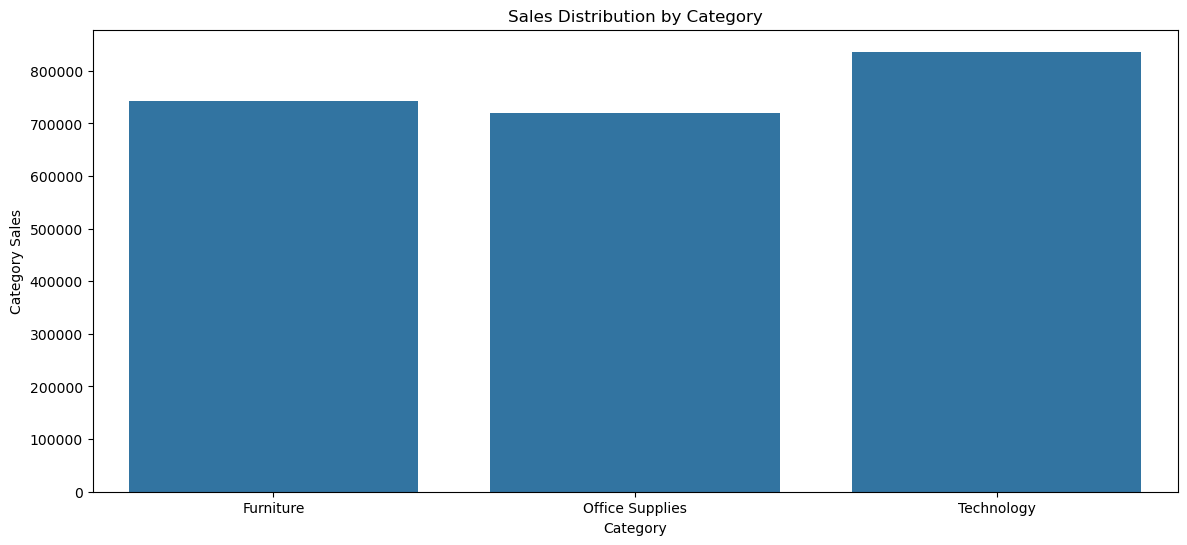

,category,category_sales
0,Furniture,741725
1,Office Supplies,719127
2,Technology,836221


In [172]:
sales_by_categories = ss_df.groupby('category')['sales'].sum().reset_index(name = 'category_sales')
plt.figure(figsize=(14,6))
sns.barplot(
    data=sales_by_categories,
    x='category',
    y='category_sales'
)
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Category Sales')

plt.show()
sales_by_categories

Question 46. Determine the most profitable month for each year.

In [175]:
profits_by_month_year =ss_df.groupby(['year','month_year'])['profit'].sum().reset_index(name ='total_profit')
profits_by_month_year['rank'] = profits_by_month_year.groupby('year')['total_profit'].rank(method ='first', ascending =False)
most_profitable_months = profits_by_month_year[profits_by_month_year['rank'] == 1]
most_profitable_months

,year,month_year,total_profit,rank
10,2011,2011-11,9292,1.0
22,2012,2012-11,12471,1.0
35,2013,2013-12,17909,1.0
38,2014,2014-03,12965,1.0


Question 47. Calculate customer repeat purchase frequency

In [182]:
repeat_customers_with_order_counts = (
    ss_df.groupby('customer_name')['order_id']
    .nunique()
    .reset_index(name='number_of_orders').loc[lambda x :x['number_of_orders'] > 1]
    .sort_values(by = 'number_of_orders',ascending =False)
)
repeat_customers_with_order_counts

,customer_name,number_of_orders
259,Emily Phan,17
586,Patrick Gardner,13
267,Erin Ashbrook,13
663,Sally Hughsby,13
791,Zuschuss Carroll,13
...,...,...
635,Ritsa Hightower,2
382,Joel Jenkins,2
119,Bryan Spruell,2
127,Carlos Meador,2


In [185]:
purchase_frequency_distribution = (
    ss_df.groupby('customer_name')['order_id']
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index(name ='number_of_customers')
    .rename(columns ={'order_id':'number_of_orders'})
)
purchase_frequency_distribution

,number_of_orders,number_of_customers
0,1,12
1,2,34
2,3,53
3,4,96
4,5,134
5,6,107
6,7,116
7,8,82
8,9,71
9,10,39


Question 48. Identify customers whose profit contribution is negative overall.

In [188]:
customers_with_neg_total_profit = ss_df.groupby('customer_name')['profit'].sum()\
                                       .reset_index(name = 'total_profit')\
                                       .loc[lambda x:x['total_profit'] < 0]\
                                       .sort_values(by ='total_profit',ascending =True)
customers_with_neg_total_profit

,customer_name,total_profit
165,Cindy Stewart,-6625
307,Grant Thornton,-4109
477,Luke Foster,-3583
693,Sharelle Roach,-3336
329,Henry Goldwyn,-2797
...,...,...
737,Thais Sissman,-3
7,Adrian Hane,-2
545,Mitch Gastineau,-1
354,Jasper Cacioppo,-1


Question 49. Build a summary table showing sales, profit, and profit margin by category.

In [189]:
ss_df.columns

Index(['category', 'city', 'country', 'customer_name', 'manufacturer',
       'order_date', 'order_id', 'postal_code', 'product_name', 'region',
       'segment', 'ship_date', 'ship_mode', 'state', 'sub-category',
       'discount', 'number_of_records', 'profit', 'profit_ratio', 'quantity',
       'sales', 'year', 'month_year', 'shipping_days', 'profit_to_sales_ratio',
       'z_scores_profit'],
      dtype='object')

In [191]:
ss_df['profit_to_sales_ratio'].describe()

count    9992.000000
mean        0.120216
std         0.469870
min        -4.000000
25%         0.064208
50%         0.269528
75%         0.372549
max         1.000000
Name: profit_to_sales_ratio, dtype: float64

,total_sales,total_profit,profit_margin
category,,,
Furniture,741725,18456,0.024883
Office Supplies,719127,122475,0.170311
Technology,836221,145429,0.173912


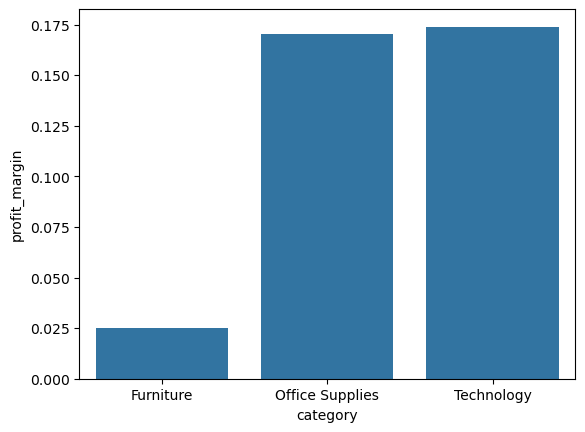

In [195]:
summary_table = ss_df.groupby('category').agg(
    total_sales=('sales','sum'),
    total_profit=('profit','sum')
)
summary_table['profit_margin'] = (
    summary_table['total_profit'] / summary_table['total_sales']
)

sns.barplot(data=summary_table.reset_index(), x='category', y='profit_margin')
summary_table

Question 50. Create a dashboard-style summary showing top regions, categories, and customers by sales.

In [196]:
top_regions = (
    ss_df.groupby('region')['sales']
    .sum()
    .reset_index(name='total_sales')
    .sort_values(by='total_sales', ascending=False)
)
top_categories = (
    ss_df.groupby('category')['sales']
    .sum()
    .reset_index(name='total_sales')
    .sort_values(by='total_sales', ascending=False)
)
top_customers = (
    ss_df.groupby('customer_name')['sales']
    .sum()
    .reset_index(name='total_sales')
    .sort_values(by='total_sales', ascending=False)
    .head(10)
)

print("Top Regions by Sales")
print(top_regions)

print("\nTop Categories by Sales")
print(top_categories)

print("\nTop 10 Customers by Sales")
print(top_customers)

Top Regions by Sales
    region  total_sales
3     West       725514
1     East       678553
0  Central       501256
2    South       391750

Top Categories by Sales
          category  total_sales
2       Technology       836221
0        Furniture       741725
1  Office Supplies       719127

Top 10 Customers by Sales
          customer_name  total_sales
686         Sean Miller        25042
730        Tamara Chand        19050
622        Raymond Buch        15117
757        Tom Ashbrook        14596
6         Adrian Barton        14476
441        Ken Lonsdale        14175
671        Sanjit Chand        14145
334        Hunter Lopez        12875
672        Sanjit Engle        12209
156  Christopher Conant        12128


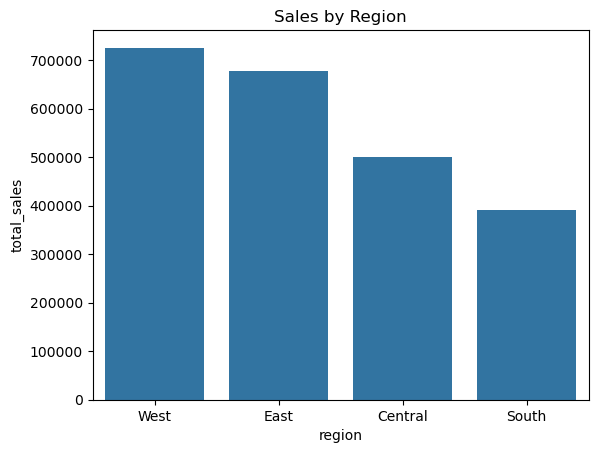

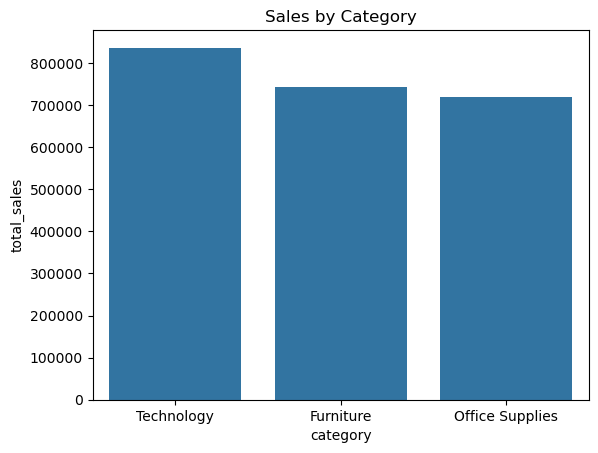

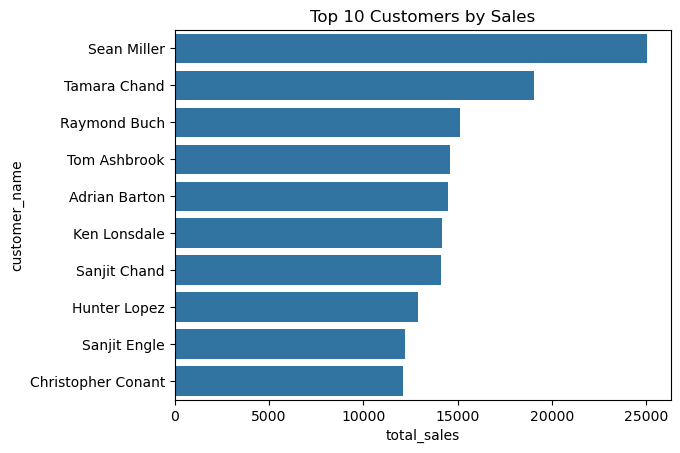

In [199]:
sns.barplot(data=top_regions, x='region', y='total_sales')
plt.title("Sales by Region")
plt.show()

sns.barplot(data=top_categories, x='category', y='total_sales')
plt.title("Sales by Category")
plt.show()

sns.barplot(data=top_customers, x='total_sales', y='customer_name')
plt.title("Top 10 Customers by Sales")
plt.show()